In [ ]:
!pip install git+https://github.com/Koziev/rusyllab

  Cloning https://github.com/Koziev/rusyllab to /tmp/pip-req-build-blug5cf8
  Running command git clone --filter=blob:none --quiet https://github.com/Koziev/rusyllab /tmp/pip-req-build-blug5cf8
  Resolved https://github.com/Koziev/rusyllab to commit c5d0ea405e9cc8233bd65503c26c0d2ad8b5cb57
  Preparing metadata (setup.py) ... done
  Created wheel for rusyllab: filename=rusyllab-0.0.4-py3-none-any.whl size=16015 sha256=aab27b4789d3319d693e5cfca1ecdbf6d6446e5ad8f28a309833c961b71dccb0
  Stored in directory: /tmp/pip-ephem-wheel-cache-6z4lcwtg/wheels/f7/17/1e/69f8774b65ec0a46e78a7e55589066bebb3a6a8cf609e835fb
Successfully built rusyllab


In [ ]:
import re
import pandas as pd
import numpy as np
import rusyllab
from scipy import stats
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter
import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import shapiro, wilcoxon

# Расчет метрик

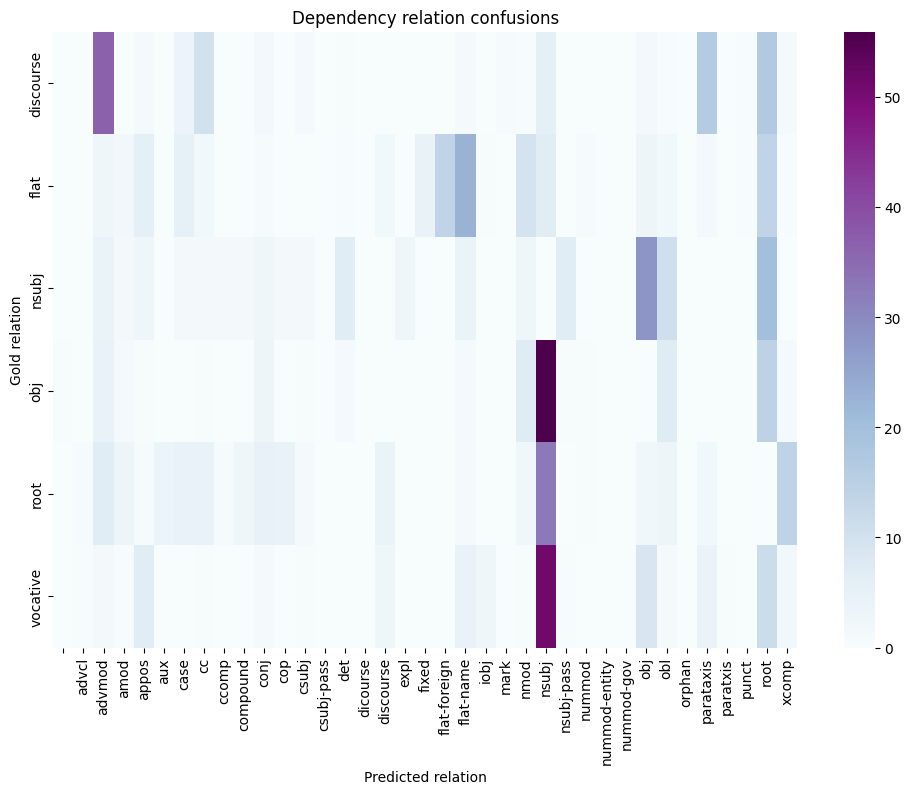

In [ ]:
# хитмеп для неверно распознанных связей

confusion_df = pd.read_csv('changes_df.csv')
heatmap_df = confusion_df.pivot_table(
    index='gold',
    columns='predicted',
    values='percent_within_gold',
    fill_value=0
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_df,
    cmap='BuPu'
)

plt.xlabel('Predicted relation')
plt.ylabel('Gold relation')

plt.title('Dependency relation confusions')

plt.savefig(
    'dependency_confusion_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()



# Графики

In [ ]:
# граифики распределения метрик (боксплоты)

for metric in metrics:

    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=data,
        x='speaker',
        y=metric
    )

    plt.title(f'{metric}: Child vs Adult')

    # сохраняем график
    plt.savefig(f'{metric}_boxplot.png', dpi=300, bbox_inches='tight')

    plt.close()

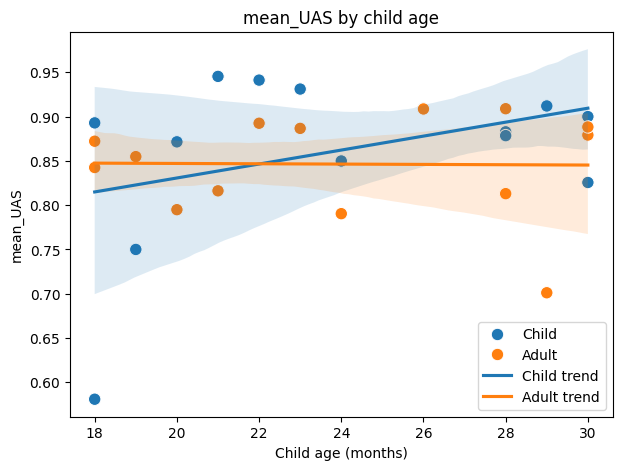

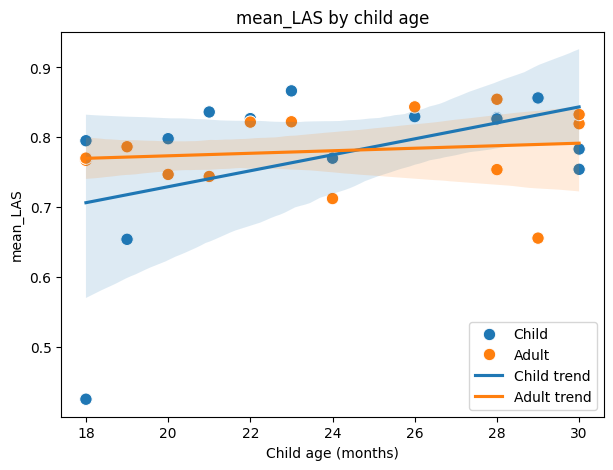

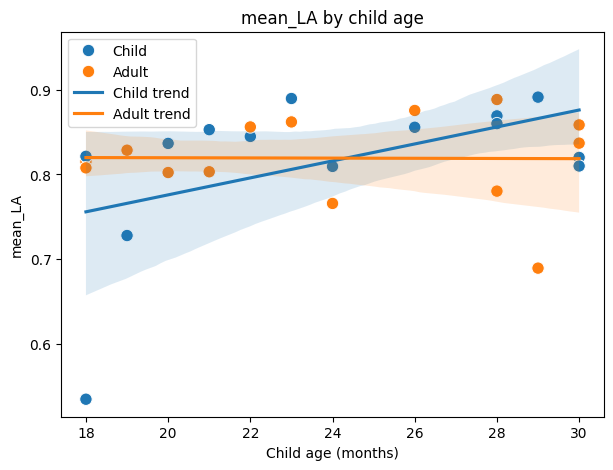

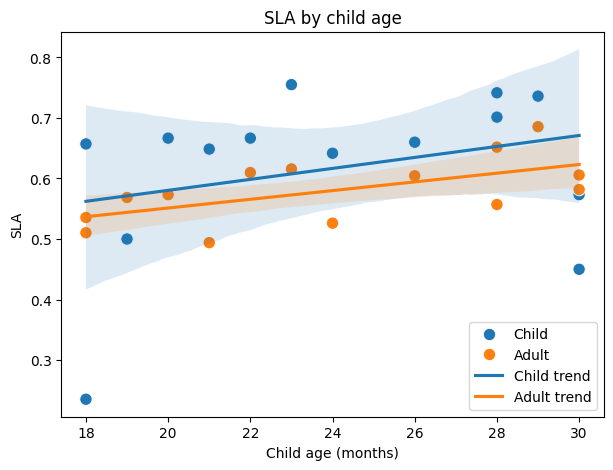

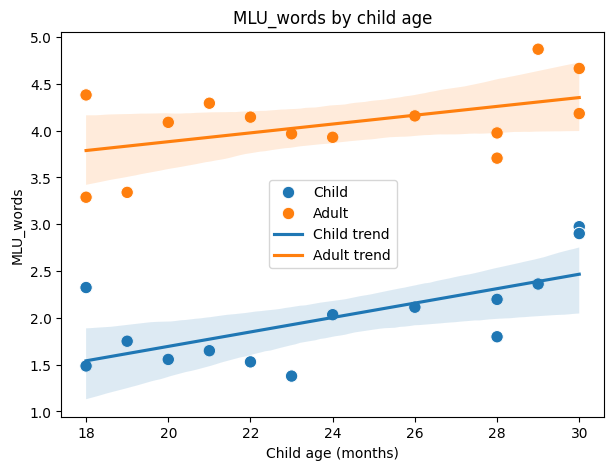

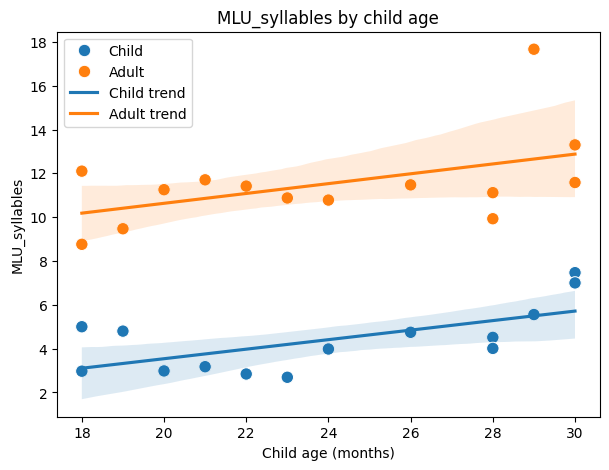

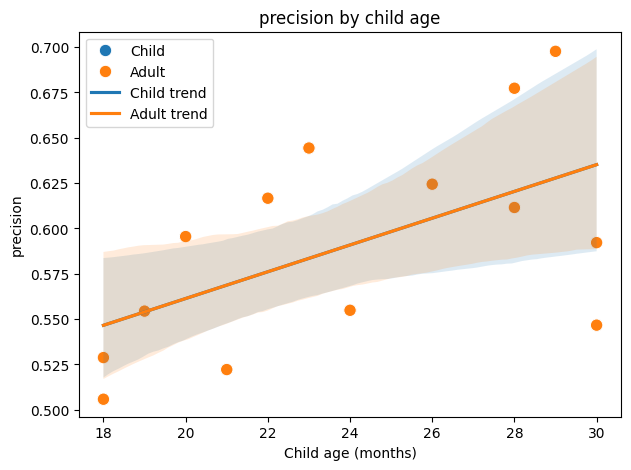

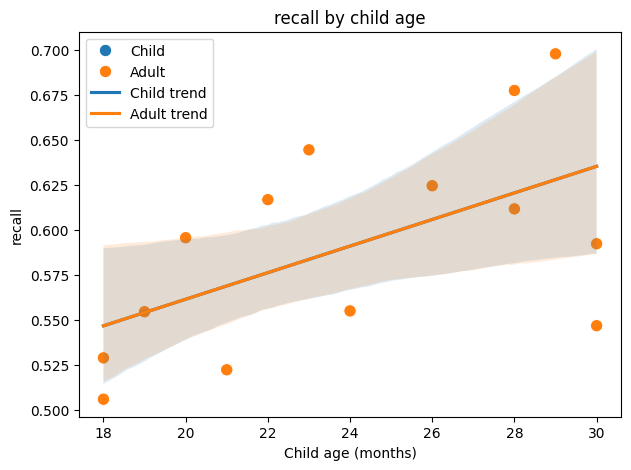

In [ ]:
# scatterplot + линия тренда, чтобы отследить общую динамику в качестве синтаксического парсинга
for metric in metrics:

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=data,
        x='child_age',
        y=metric,
        hue='speaker',
        s=80
    )

    sns.regplot(
        data=data[data['speaker'] == 'Child'],
        x='child_age',
        y=metric,
        scatter=False,
        label='Child trend'
    )

    sns.regplot(
        data=data[data['speaker'] == 'Adult'],
        x='child_age',
        y=metric,
        scatter=False,
        label='Adult trend'
    )

    plt.title(f'{metric} by child age')
    plt.xlabel('Child age (months)')
    plt.ylabel(metric)

    plt.legend()

    plt.savefig(
        f'{metric}_age_scatter_trend.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

In [ ]:
numeric_cols = data.select_dtypes(include=['number']).columns
grouped_by_age = data.groupby(['child_age', 'speaker'])[numeric_cols].agg(['mean', 'std'])
grouped_by_age.to_csv('metrics_grouped_by_age.csv')
grouped_by_age.head()

child_age        words             sentences             \
                       mean  std    mean         std      mean        std   
child_age speaker                                                           
18        Adult        18.0  0.0  1078.5  395.272691     276.5  47.376154   
          Child        18.0  0.0    65.5   19.091883      34.5   0.707107   
19        Adult        19.0  NaN   511.0         NaN     153.0        NaN   
          Child        19.0  NaN    70.0         NaN      40.0        NaN   
20        Adult        20.0  NaN  1533.0         NaN     375.0        NaN   
          Child        20.0  NaN   182.0         NaN     117.0        NaN   
21        Adult        21.0  NaN  1425.0         NaN     332.0        NaN   
          Child        21.0  NaN   122.0         NaN      74.0        NaN   
22        Adult        22.0  NaN  1529.0         NaN     369.0        NaN   
          Child        22.0  NaN    78.0         NaN      51.0        NaN   
23        Adult        23.0  NaN  1507.0         NaN     380.0        NaN   
          Child        23.0  NaN   135.0         NaN      98.0        NaN   
24        Adult        24.0  NaN  1426.0         NaN     363.0        NaN   
          Child        24.0  NaN   244.0         NaN     120.0        NaN   
26        Adult        26.0  NaN  1114.0         NaN     268.0        NaN   
          Child        26.0  NaN   317.0         NaN     150.0        NaN   
28        Adult        28.0  0.0   886.0   79.195959     230.5   9.192388   
          Child        28.0  0.0   224.5   91.216775     116.5  38.890873   
29        Adult        29.0  NaN  1115.0         NaN     229.0        NaN   
          Child        29.0  NaN   170.0         NaN      72.0        NaN   
30        Adult        30.0  0.0   357.5  180.312229      79.5  34.648232   
          Child        30.0  0.0   140.5  116.672619      47.5  38.890873   

                  mean_UAS           mean_LAS            ...      SLA  \
                      mean       std     mean       std  ...     mean   
child_age speaker                                        ...            
18        Adult    0.85735  0.021001  0.76875  0.002192  ...  0.52290   
          Child    0.73690  0.220617  0.61035  0.261417  ...  0.44620   
19        Adult    0.85480       NaN  0.78660       NaN  ...  0.56860   
          Child    0.75000       NaN  0.65420       NaN  ...  0.50000   
20        Adult    0.79490       NaN  0.74700       NaN  ...  0.57330   
          Child    0.87150       NaN  0.79810       NaN  ...  0.66670   
21        Adult    0.81620       NaN  0.74410       NaN  ...  0.49400   
          Child    0.94540       NaN  0.83630       NaN  ...  0.64860   
22        Adult    0.89250       NaN  0.82180       NaN  ...  0.60980   
          Child    0.94120       NaN  0.82680       NaN  ...  0.66670   
23        Adult    0.88670       NaN  0.82230       NaN  ...  0.61580   
          Child    0.93110       NaN  0.86650       NaN  ...  0.75510   
24        Adult    0.79040       NaN  0.71250       NaN  ...  0.52620   
          Child    0.84990       NaN  0.77020       NaN  ...  0.64170   
26        Adult    0.90860       NaN  0.84360       NaN  ...  0.60450   
          Child    0.90910       NaN  0.82970       NaN  ...  0.66000   
28        Adult    0.86095  0.067812  0.80420  0.071135  ...  0.60440   
          Child    0.88065  0.003041  0.82725  0.001202  ...  0.72150   
29        Adult    0.70110       NaN  0.65590       NaN  ...  0.68560   
          Child    0.91200       NaN  0.85640       NaN  ...  0.73610   
30        Adult    0.88375  0.006435  0.82610  0.009334  ...  0.59380   
          Child    0.86280  0.052609  0.76880  0.020506  ...  0.51165   

                            MLU_words           MLU_syllables            \
                        std      mean       std          mean       std   
child_age speaker                                                         
18        Adult    0.017819   3.83435  0.

In [ ]:
grouped_by_age.columns = [
    '_'.join(col).strip('_')
    if isinstance(col, tuple)
    else col
    for col in grouped_by_age.columns.values
]

grouped_by_age = grouped_by_age.reset_index()

# список метрик
metrics = [
    'mean_UAS',
    'mean_LAS',
    'mean_LA',
    'SLA',
    'MLU_words',
    'MLU_syllables',
    'precision', 'recall'
]

for metric in metrics:

    plt.figure(figsize=(7, 5))

    sns.lineplot(
        data=grouped_by_age,
        x='child_age',
        y=f'{metric}_mean',
        hue='speaker',
        marker='o'
    )

    plt.title(f'{metric}: Child vs Adult by Age')

    plt.xlabel('Child age (months)')
    plt.ylabel(metric)

    plt.savefig(
        f'age_{metric}_lineplot.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()